# WCC: deep-field depth per filter (cosmology)

Galaxy-evolution and cosmology programs are planned in limiting magnitude: how deep does a field
get in each band for a given investment of time? This notebook uses `wcc_etc` to ask **what
5 sigma point-source depth the Wide-field Context Camera (WCC) reaches in u, g, r, i, z and the
broad "bb" filter as a function of exposure time, and how much stacking short frames costs.**

Install: [repository setup](../../README.md); browse the [gallery index](../README.md).

**At a glance** · Starter · Package: `wcc_etc`

- **Question:** the bold science question above; aim for one observing decision from the main comparison plot.
- **Prerequisite:** installed [gallery environment](../../README.md), basic Python and magnitudes/SNR.
- **Cost:** scalar/spectral calculations, normally seconds to minutes; cache downloads can add time.
- **First edit:** the Parameters cell below. Restart Kernel and Run All after each change.
- **Output:** plotted comparison plus printed achieved metrics/status.
- **Caveat:** ETC model assumptions and the source template determine the answer; exposure excludes operational overhead.

Section introductions describe the original defaults; the Parameters cell and current outputs are authoritative after edits.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import wcc_etc
from wcc_etc import Simulation, get_scene

wcc_etc.set_wcc_style()

## Parameters
Change these inputs first; leave the calculation cells intact.


In [2]:
EXPTIMES = np.array([30, 100, 300, 1000, 3000, 10000])  # seconds
STACK_TIME = 3000.0                                    # fixed stack budget, seconds
READ_COUNTS = (1, 10, 100)


## 1. Build one simulation per filter

A flat-spectrum (AB) point source at AB = 24 on the zodiacal background, in-focus IMX455 sensor.

In [3]:
filters = ["zwo:u", "zwo:g", "zwo:r", "zwo:i", "zwo:z", "zwo:bb"]
sims = {f: Simulation.from_sensorfilter(f, get_scene("flat", mag=24, magsys="abmag")) for f in filters}
for f, s in sims.items():
    print(f"{f:7s}: pivot {s.sensor.bandpass.pivot().value:6.0f} A, "
          f"5 sigma on AB = 24 in {s.get_image_exptime_for_snr(5, warn=False)['time_s']:6.1f} s")

[wcc_etc] note: even n_pixels is rounded up by 1 to center the PSF peak (shown once).


zwo:u  : pivot   3765 A, 5 sigma on AB = 24 in   83.4 s
zwo:g  : pivot   4773 A, 5 sigma on AB = 24 in    8.0 s
zwo:r  : pivot   6140 A, 5 sigma on AB = 24 in   15.0 s


zwo:i  : pivot   7610 A, 5 sigma on AB = 24 in   43.7 s
zwo:z  : pivot   9012 A, 5 sigma on AB = 24 in  132.6 s
zwo:bb : pivot   5821 A, 5 sigma on AB = 24 in    5.2 s


## 2. The filter set

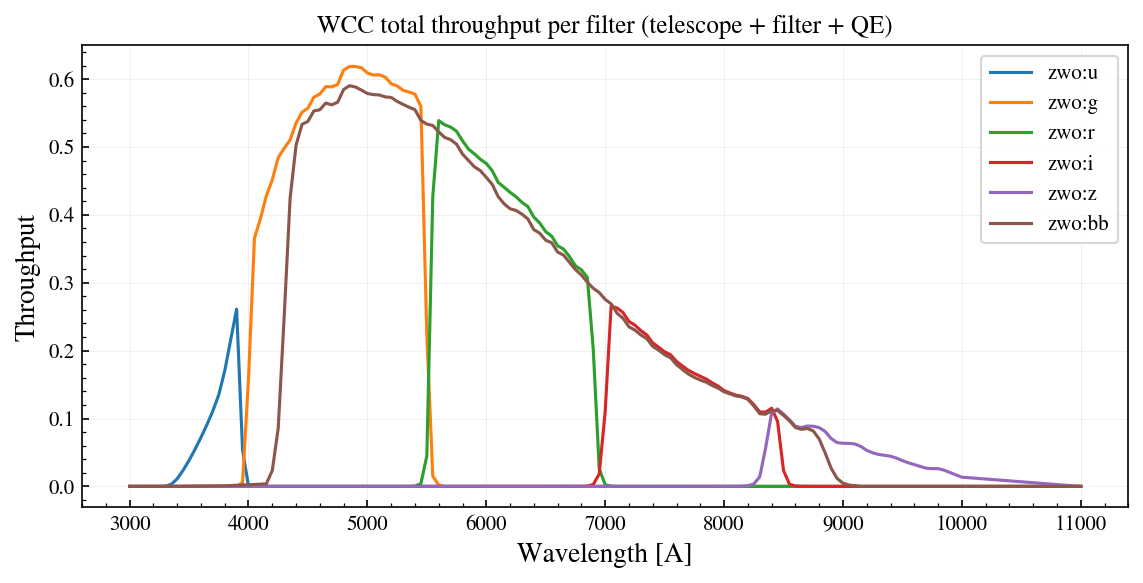

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for f, s in sims.items():
    wcc_etc.plot_bandpass_mpl(s.sensor, ax=ax, label=f)
ax.set(title="WCC total throughput per filter (telescope + filter + QE)")
ax.legend()
plt.show()

## 3. Limiting magnitude versus exposure time

For each filter and exposure time the SNR is computed on a grid of magnitudes and the 5 sigma
crossing is interpolated. `snr_crossing` only interpolates when the unsaturated samples are finite,
monotonic and bracket SNR = 5; otherwise it returns NaN and says why, instead of silently returning
a grid endpoint.

zwo:u  : 5 sigma AB depth  22.90  24.19  25.35  26.55  27.53  28.42
zwo:g  : 5 sigma AB depth  25.41  26.66  27.71  28.71  29.47  30.20
zwo:r  : 5 sigma AB depth  24.74  26.00  27.06  28.06  28.83  29.57


zwo:i  : 5 sigma AB depth  23.60  24.87  25.99  27.08  27.92  28.71
zwo:z  : 5 sigma AB depth  22.41  23.70  24.84  26.01  26.92  27.76
zwo:bb : 5 sigma AB depth  25.86  27.06  28.03  28.92  29.62  30.32
                              30    100    300   1000   3000  10000   s


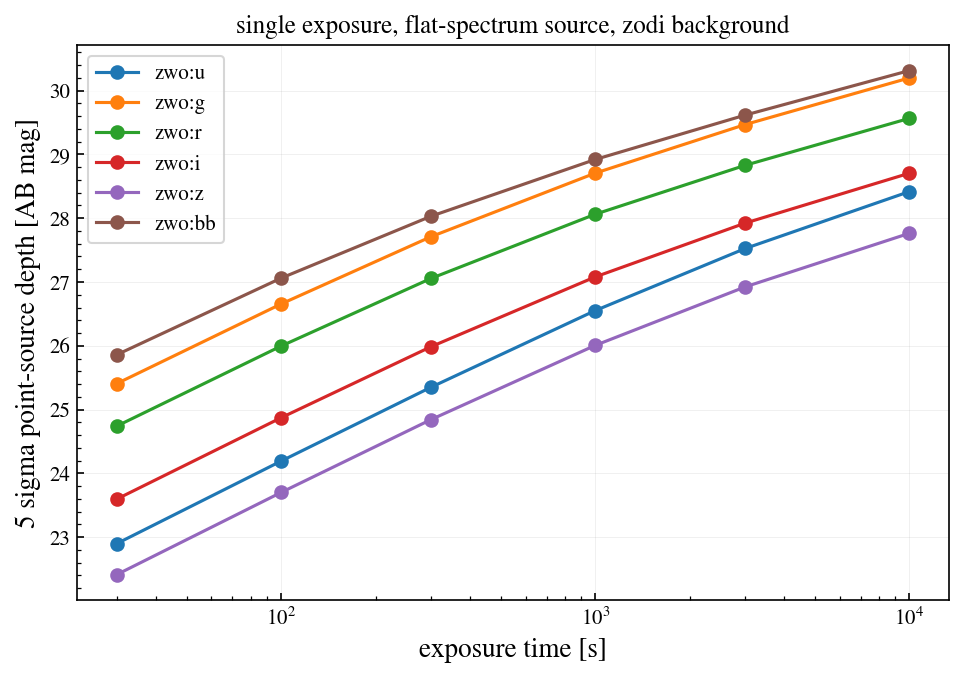

g-band depth gain: 2.30 mag/decade (30 -> 300 s), 1.40 mag/decade (3000 -> 10000 s); limits: 2.5 read-noise-limited, 1.25 sky-limited


In [5]:
def snr_crossing(mags, snr, saturated, target=5.0):
    """Magnitude at which SNR falls through `target`; NaN (with a reason) if not measurable."""
    mags, snr = np.asarray(mags, float), np.asarray(snr, float)
    ok = np.isfinite(snr) & (snr > 0) & ~np.asarray(saturated, bool)
    m, s = mags[ok], snr[ok]
    if len(m) < 2 or np.any(np.diff(s) >= 0):
        print("  crossing not measurable: fewer than 2 valid samples or SNR not monotonic"); return np.nan
    if not (s[0] > target > s[-1]):
        print(f"  crossing not bracketed: SNR {s[-1]:.2f}-{s[0]:.2f} on AB {m[0]:.1f}-{m[-1]:.1f}"); return np.nan
    return np.interp(np.log10(target), np.log10(s[::-1]), m[::-1])

exptimes = EXPTIMES
mags = np.arange(20, 32.01, 0.5)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
depth = {}
for f, s in sims.items():
    depth[f] = []
    for t in exptimes:
        res = s.get_image_snr(t, mags=mags, warn=False)
        depth[f].append(snr_crossing(mags, res["snr"], res["saturated"]))
    ax.semilogx(exptimes, depth[f], "o-", label=f)
    print(f"{f:7s}: 5 sigma AB depth  " + "  ".join(f"{d:5.2f}" for d in depth[f]))
print(" " * 27 + "  ".join(f"{t:5d}" for t in exptimes) + "   s")
ax.set(xlabel="exposure time [s]", ylabel="5 sigma point-source depth [AB mag]",
       title="single exposure, flat-spectrum source, zodi background")
ax.legend()
plt.show()

slope = lambda f, i, j: (depth[f][j] - depth[f][i]) / np.log10(exptimes[j] / exptimes[i])
print(f"g-band depth gain: {slope('zwo:g', 0, 2):.2f} mag/decade ({exptimes[0]:g} -> {exptimes[2]:g} s), "
      f"{slope('zwo:g', 4, 5):.2f} mag/decade ({exptimes[4]:g} -> {exptimes[5]:g} s); "
      "limits: 2.5 read-noise-limited, 1.25 sky-limited")

## 4. The cost of stacking

Section 3 is a single read of length t. A fixed-duration stack is different: the same 3000 s of
r band taken as one frame, as 10 x 300 s, or as 100 x 30 s adds read noise once per frame; the
well depth sets how long a single frame can be.

In [6]:
s = sims["zwo:r"]
for n_reads in READ_COUNTS:
    res = s.get_image_snr(STACK_TIME, mags=mags, n_reads=n_reads, warn=False)
    d = snr_crossing(mags, res["snr"], res["saturated"])
    print(f"{STACK_TIME:g} s as {n_reads:3d} x {STACK_TIME/n_reads:g} s: 5 sigma depth AB = {d:.2f}")


3000 s as   1 x 3000 s: 5 sigma depth AB = 28.83
3000 s as  10 x 300 s: 5 sigma depth AB = 28.37
3000 s as 100 x 30 s: 5 sigma depth AB = 27.35


## Reference-run takeaway (original defaults)

**Historical baseline prose:** numerical values below describe the pre-review default run. Use the freshly printed values and plots for current results, especially where this revision corrects an estimator.

In a single 300 s exposure WCC reaches 5 sigma point-source depths of AB ~ 28.0 (bb), 27.7 (g),
27.1 (r), 26.0 (i), 25.4 (u) and 24.8 (z); an hour gets roughly one magnitude deeper and 10^4 s
reaches AB ~ 30 in g and bb. Two limits bracket how depth grows with the length of a single read:
when a fixed read noise dominates and the source shot noise is weak, the limiting flux scales as
1/t (2.5 mag per decade); once the sky dominates it scales as 1/sqrt(t) (1.25 mag per decade). The
g depth gains 2.30 mag per decade from 30 to 300 s, close to the read-noise-limited slope, and 1.40
mag per decade from 3000 to 10000 s, approaching the sky-limited slope, because the zodiacal sky
takes hundreds of seconds to exceed the read noise per pixel. A fixed-duration stack does not follow
either curve: splitting 3000 s of r band into 10 x 300 s costs 0.46 mag and into 100 x 30 s costs
1.48 mag relative to one read, so deep fields should use the longest frames the brightest stars in
the field allow.

## Try this

1. Multiply EXPTIMES by 2. Report the r-band depth gain near 300 s and whether it is photon limited.
2. Set STACK_TIME to 6000. Compare the depth penalty for READ_COUNTS=(1,10,100).

**Extension:** Replace the flat source with a galaxy SED; point-source depth is not galaxy completeness.

Bring back one figure, the requested and achieved metric, an observing decision, and the main limitation.
